In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/loan_predict.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df = df.drop('Loan_ID', axis=1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


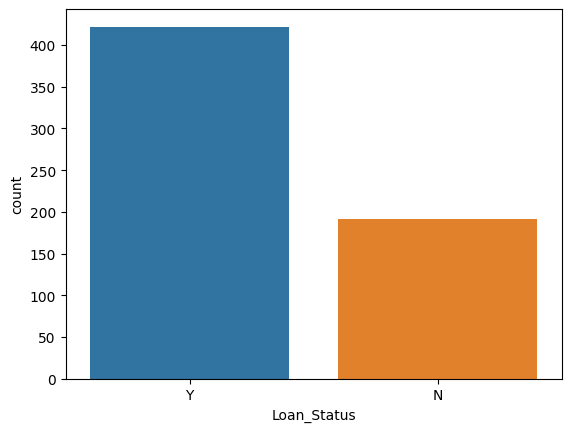

In [7]:
sns.countplot(x='Loan_Status', data=df, hue='Loan_Status');

In [8]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

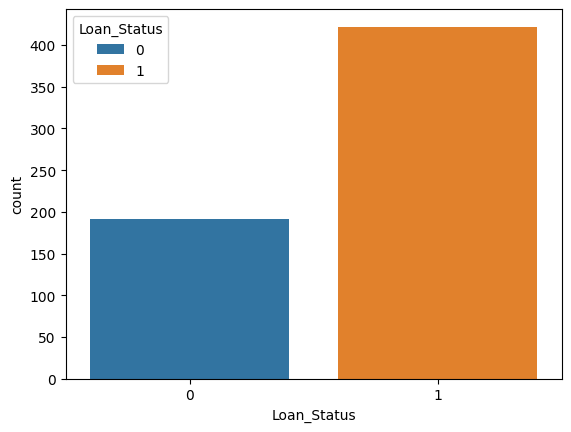

In [9]:
sns.countplot(x='Loan_Status', data=df, hue='Loan_Status');

<Axes: >

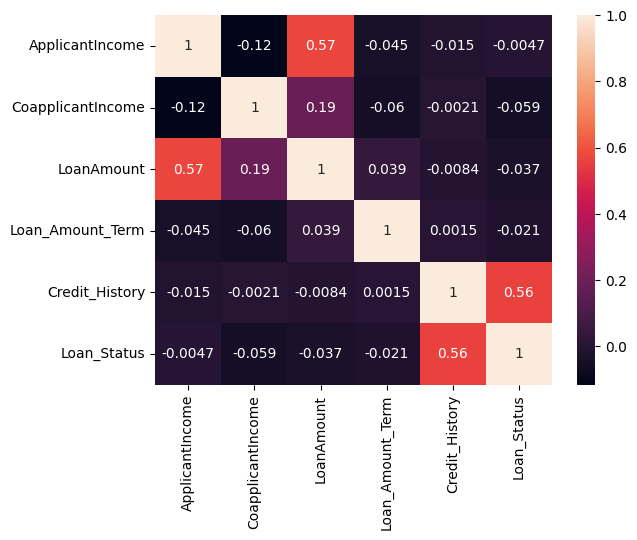

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

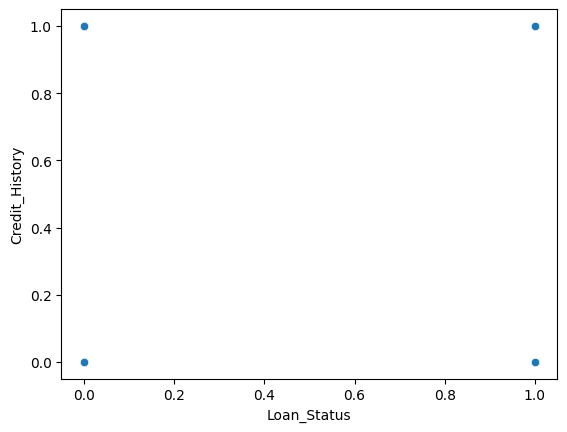

In [11]:
sns.scatterplot(x='Loan_Status', y='Credit_History', data=df);

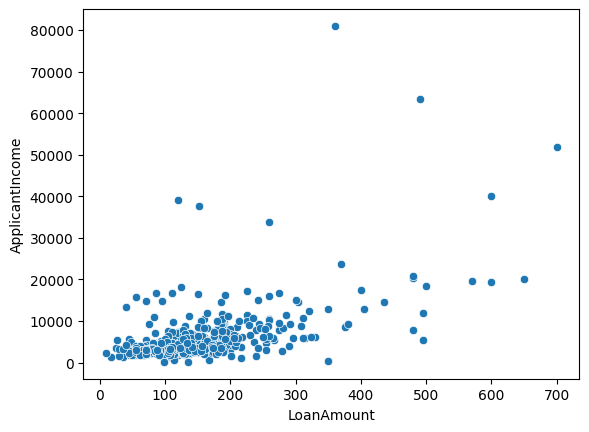

In [12]:
sns.scatterplot(x='LoanAmount', y='ApplicantIncome', data=df);

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.impute import KNNImputer, SimpleImputer

In [14]:
X = df.drop("Loan_Status", axis=1)

In [15]:
y = df['Loan_Status']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=104, stratify=y)

In [17]:
num_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
cat_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

In [18]:
num_features

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [19]:
cat_features

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Credit_History']

In [20]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [21]:
cat_tranformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_tranformer, cat_features),
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [23]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LogisticRegressionCV(cv=10,
                                   penalty='l1',
                                   solver='liblinear',
                                   Cs=10,
                                   max_iter=100_000,
                                   n_jobs=-1,
                                  random_state=104,
                                  class_weight='balanced'))
])

In [24]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [25]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [26]:
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
y_pred_train_proba = pipe.predict_proba(X_train)[:, 1]

In [27]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_model.C_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение C: [0.04641589]
Лучшее значение l1_ratio: [None]


In [28]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
roc_auc_train = roc_auc_score(y_train, y_pred_train_proba)
roc_auc_test = roc_auc_score(y_test, y_pred_proba)

In [29]:
accuracy

0.7886178861788617

In [30]:
recall

0.9529411764705882

In [31]:
precision

0.7864077669902912

In [32]:
roc_auc_train

0.7958784538903234

In [33]:
roc_auc_test

0.7390092879256966

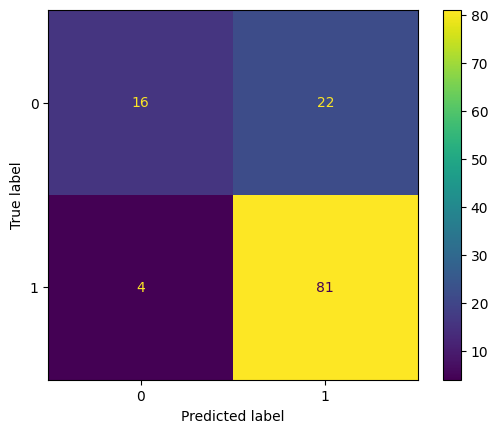

In [34]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test);

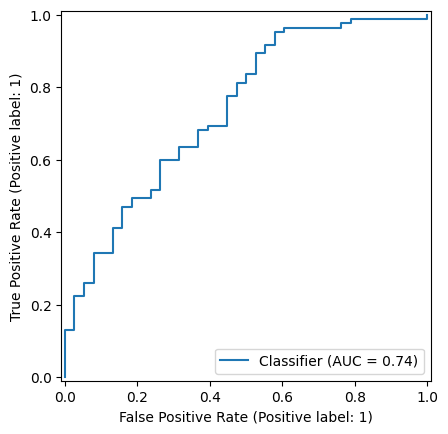

In [35]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

In [36]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [37]:
y_pred_full_proba = pipe.predict_proba(X)[:,1]

In [38]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_final_model.C_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение C: [0.04641589]
Лучшее значение l1_ratio: [None]


In [39]:
roc_auc_full = roc_auc_score(y, y_pred_full_proba)

In [40]:
roc_auc_full

0.7896796011058452

In [41]:
test_df = pd.DataFrame([
    {
        'Gender': 'Male', 
        'Married': 'Yes', 
        'Dependents': '0', 
        'Education': 'Graduate',
        'Self_Employed': 'No', 
        'ApplicantIncome': 9500, 
        'CoapplicantIncome': 4500,
        'LoanAmount': 120, 
        'Loan_Amount_Term': 360, 
        'Credit_History': 1.0, 
        'Property_Area': 'Urban'
    },
    {
        'Gender': 'Male', 
        'Married': 'No', 
        'Dependents': '3', 
        'Education': 'Not Graduate',
        'Self_Employed': 'Yes', 
        'ApplicantIncome': 2100, 
        'CoapplicantIncome': 0,
        'LoanAmount': 550, 
        'Loan_Amount_Term': 180, 
        'Credit_History': 0.0, 
        'Property_Area': 'Rural'
    }
])

In [42]:
test_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,9500,4500,120,360,1.0,Urban
1,Male,No,3,Not Graduate,Yes,2100,0,550,180,0.0,Rural


In [43]:
probabilities = pipe.predict_proba(test_df)[:, 1]
accepted = pipe.predict(test_df)

In [44]:
print(f"--- Вероятность одобрения для надежного клиента: {probabilities[0]:.2%}")
print(f"--- Вероятность одобрения для рискованного клиента: {probabilities[1]:.2%}")
for el, i in enumerate(accepted):
    if el == 1:
        print(f"--- Клиенту номер {i+1} кредит одобрен!")
    elif el == 0:
        print(f"--- Клиенту номер {i+1} кредит отклонен!")

--- Вероятность одобрения для надежного клиента: 59.96%
--- Вероятность одобрения для рискованного клиента: 18.72%
--- Клиенту номер 2 кредит отклонен!
--- Клиенту номер 1 кредит одобрен!


In [45]:
class_percents = df['Loan_Status'].value_counts(normalize=True) * 100

baseline_string = f"0: {class_percents[0]:.1f}%, 1: {class_percents[1]:.1f}%"
print(f"{baseline_string}")

0: 31.3%, 1: 68.7%


In [46]:
import json
import os

advanced_report = {
    "project": "Loan Approval Prediction",
    "model": "LogisticRegressionCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "cv": best_model.cv,
        "penalty": best_model.penalty,
        "solver":best_model.solver,
        "C": best_model.C_.tolist()[0],
    },
    "final_parameters": {
        "cv": best_final_model.cv,
        "penalty": best_final_model.penalty,
        "solver":best_final_model.solver,
        "C": best_final_model.C_.tolist()[0],
    },
    "metrics": {
        "Accuracy Score": accuracy,
        "Precision Score": precision,
        "Recall": recall,
        "ROC AUC Score Train": roc_auc_train,
        "ROC AUC Score Test": roc_auc_test,
        "ROC AUC Score Full": roc_auc_full,
        "Class Balance": baseline_string
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [47]:
from joblib import dump, load

In [48]:
dump(pipe, "model/loan_approval_predict_logistic_regression_cv_2026_v1.pkl")

['model/loan_approval_predict_logistic_regression_cv_2026_v1.pkl']

In [49]:
loaded_pipe = load("model/loan_approval_predict_logistic_regression_cv_2026_v1.pkl")

In [50]:
loaded_pipe.predict(test_df)

array([1, 0])

In [51]:
loaded_pipe.predict_proba(test_df)[:, 1]

array([0.59955578, 0.18719989])